<center> <img src="https://miro.medium.com/v2/resize:fit:1200/1*lbDXL0IuitCRz4mpZ7MmfQ.png" width=55% > </center>

<br><br>

<center> 
    <font size="6">Final Lab (Part 2): Image Classification using Convolutional Neural Networks </font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, 24th October, 2025 (Amsterdam time)</font> 
</center>

<br><br>

***

<br><br>

<center>

Student1 ID:  \
Student1 Name: 

Student2 ID: \
Student2 Name: 

Student3 ID: \
Student3 Name: 

( Student4 ID: \
Student4 Name: )

</center>

### **Coding Guidelines**

Your code must be handed in this Jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Final Lab: Image Classification Assignment. Please also fill out your names and IDs above.

For full credit, make sure your notebook follows these guidelines:

- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Understand the problem as much as you can. When answering a question, provide evidence (qualitative and/or quantitative results, references to papers, figures, etc.) to support your arguments. Not everything might be explicitly asked for, so think about what might strengthen your arguments to make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Add a number, a title, and, if applicable, the name and unit of variables in a table, and name and unit of axes and legends in a figure.

**Late submissions are not allowed.** Assignments submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance to avoid last-minute system failure issues.

**Environment:** Since this is a project-based assignment, you are free to use any feature descriptor and machine learning tools (e.g., K-means, SVM). You should use Python for your implementation. You are free to use any Python library for this assignment, but make sure to provide a conda environment file!

**Plagiarism Note:** Keep in mind that plagiarism (submitted materials which are not your work) is a serious offense and any misconduct will be addressed according to university regulations. This includes using generative tools such as ChatGPT.

**Ensure that you save all results/answers to the questions (even if you reuse some code).**

### **Report Preparation**

Your tasks include the following:

1. **Report Preparation:** For both parts of the final project, students are expected to prepare a report. The report should include all details on implementation approaches, analysis of results for different settings, and visualizations illustrating experiments and performance of your implementation. Grading will be based on the report, so it should be as self-contained as possible. If the report contains faulty results or ambiguities, TAs can refer to your code for clarification. 

2. **Explanation of Results:** Do not just provide numbers without explanation. Discuss different settings to show your understanding of the material and processes involved.

3. **Quantitative Evaluation:** For quantitative evaluation, you are expected to provide the results based on performance (accuracy, learning loss and learning curves). 

4. **Aim:** Understand the basic Image Classification pipeline using Convolutional Neural Nets (CNN's).

5. **Working on Assignments:** Students should work in assigned groups for **two** weeks. Any questions can be discussed on ED.

    - **Submission:** Submit your source code and report together in a zip file (`ID1_ID2_ID3_part2.zip`). The report should be a maximum of 10 pages (single-column, including tables and figures, excluding references and appendix). Express thoughts concisely. Tables and figures must be accompanied by a description. Number them and, if applicable, name variables in tables, and label axes in figures.

6. **Hyperparameter Search:** In your experiments, remember to perform a hyperparameter search to find the optimal settings for your model(s). Clearly document the search process, the parameters you explored, and how they influenced the performance of your model.

8. **Format and Testing:** The report should be in **PDF format**, and the code in **.ipynb format**. Test that all functionality works as expected in the notebook.

### **Overview**

- [Section 1: Image Classification on CIFAR-100 (0 points)](#section-1)
- [Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)](#section-2)
- [Section 3: TwoLayerNet Architecture (2 points)](#section-3)
- [Section 4: ConvNet Architecture (2 points)](#section-4)
- [Section 5: Preparation of Training (7 points)](#section-5)
- [Section 6: Training the Networks (5 points)](#section-6)
- [Section 7: Setting Up the Hyperparameters (14 points)](#section-7)
- [Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)](#section-8)
- [Section 9: Fine-tuning ConvNet on STL-10 (14 points)](#section-9)
- [Section 10: Bonus Challenge (optional)](#section-10)
- [Section X: Individual Contribution Report (Mandatory)](#section-x)

### **Section 1: Image Classification on CIFAR-100 (0 points)**

The goal of this lab is to implement an image classification system using Convolutional Neural Networks (CNNs) that can identify objects from a set of classes in the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). You will implement and compare two different architectures: a simple two-layer network and a ConvNet based on the LeNet architecture.

The CIFAR-100 dataset contains 32x32 pixel RGB images, categorized into 100 different classes. The dataset will be automatically downloaded and loaded using the code provided in this notebook.

You will train and test your classification system using the entire CIFAR-100 dataset. Ensure that the test images are excluded from training to maintain a fair evaluation of the model's performance.

In [3]:
import os
from pathlib import Path
from datetime import datetime
import random
import math
import json

## pytorch library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision import datasets as tv_datasets
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset, random_split
from torch.utils.tensorboard import SummaryWriter

## we add some libraries

## data processing
import numpy as np
import pandas as pd

## visualization
import plotly.express as px
import matplotlib.pyplot as plt
from PIL import Image


## higher quality figure output
%config InlineBackend.figure_format = 'svg'

## Machine Learning library
import sklearn as skl

## hyperparameter tuning
import optuna


####################################################################################

# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

# Load the CIFAR-100 training set
train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Load the CIFAR-100 test set
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Create data loaders for the entire CIFAR-100 dataset
train_data_loader = DataLoader(train_set, shuffle=True)
test_data_loader = DataLoader(test_set, shuffle=False)

# Define CIFAR-100 superclasses and their subclasses
superclasses = {
    'aquatic mammals': ['beaver', 'dolphin', 'otter', 'seal', 'whale'],
    'fish': ['aquarium_fish', 'flatfish', 'ray', 'shark', 'trout'],
    'flowers': ['orchid', 'poppy', 'rose', 'sunflower', 'tulip'],
    'food containers': ['bottle', 'bowl', 'can', 'cup', 'plate'],
    'fruit and vegetables': ['apple', 'mushroom', 'orange', 'pear', 'sweet_pepper'],
    'household electrical devices': ['clock', 'keyboard', 'lamp', 'telephone', 'television'],
    'household furniture': ['bed', 'chair', 'couch', 'table', 'wardrobe'],
    'insects': ['bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'],
    'large carnivores': ['bear', 'leopard', 'lion', 'tiger', 'wolf'],
    'large man-made outdoor things': ['bridge', 'castle', 'house', 'road', 'skyscraper'],
    'large natural outdoor scenes': ['cloud', 'forest', 'mountain', 'plain', 'sea'],
    'large omnivores and herbivores': ['camel', 'cattle', 'chimpanzee', 'elephant', 'kangaroo'],
    'medium-sized mammals': ['fox', 'porcupine', 'possum', 'raccoon', 'skunk'],
    'non-insect invertebrates': ['crab', 'lobster', 'snail', 'spider', 'worm'],
    'people': ['baby', 'boy', 'girl', 'man', 'woman'],
    'reptiles': ['crocodile', 'dinosaur', 'lizard', 'snake', 'turtle'],
    'small mammals': ['hamster', 'mouse', 'rabbit', 'shrew', 'squirrel'],
    'trees': ['maple_tree', 'oak_tree', 'palm_tree', 'pine_tree', 'willow_tree'],
    'vehicles 1': ['bicycle', 'bus', 'motorcycle', 'pickup_truck', 'train'],
    'vehicles 2': ['lawn_mower', 'rocket', 'streetcar', 'tank', 'tractor']
}

# List of all CIFAR-100 classes
classes = ('apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 
           'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
           'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
           'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
           'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
           'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
           'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
           'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 
           'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 
           'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm')

# Create a mapping of class names to their indices
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

# Create a mapping of superclasses to their corresponding class indices
superclass_to_indices = {supcls: [class_to_idx[cls] for cls in subclasses] for supcls, subclasses in superclasses.items()}

print("Data loaders for CIFAR-100 are ready for use.")

Files already downloaded and verified
Files already downloaded and verified
Data loaders for CIFAR-100 are ready for use.


In [4]:
## save random image from dataset
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title('Sample images')
    plt.savefig('samples.svg')
    plt.show()

<a id="section-2"></a>
### **Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)**

In this section, you will implement a function to visualize the CIFAR-100 dataset, including **all** superclasses and their corresponding subclasses. Your implementation should provide a clear and organized overview of the dataset's diversity.

You add the figure(s) to appendix of your report and refer to it in the main text.

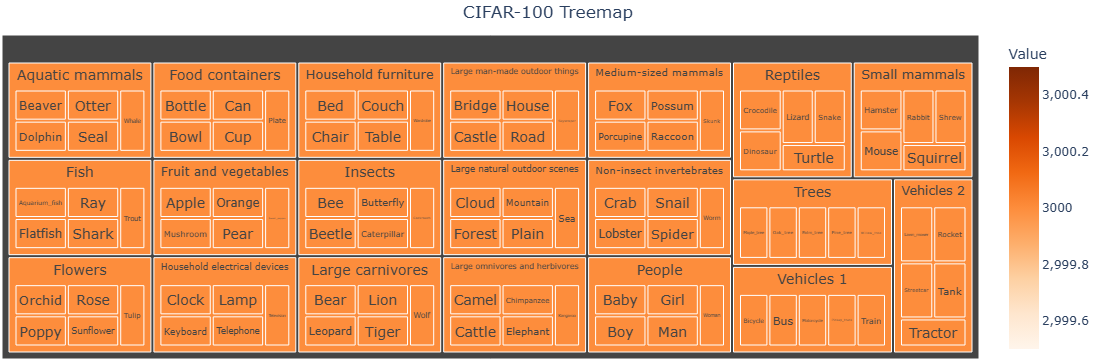

<Figure size 640x480 with 0 Axes>

In [5]:
# YOUR CODE HERE
## define a function to visualize CIFAR_100 dataset

def visualize_sub_super(superclasses, train_set, test_set, classes):
    """
    superclasses: dict[superclass -> list of subclass names]
    train_set, test_set: iterable of (image, label_index)
    classes: list of CIFAR-100 class names in label index order
    """

    # Map label index (superclasses and their subclasses)
    label_to_super = {}
    for sup, subs in superclasses.items():
        for sub in subs:
            idx = classes.index(sub)  
            label_to_super[idx] = sup

    # Initialize the counters in train and test set
    train_counts = {sup: 0 for sup in superclasses}
    test_counts  = {sup: 0 for sup in superclasses}

    # Count the number of samples in the train and test set
    for _, label in train_set:
        sup = label_to_super.get(label)
        if sup is not None:
            train_counts[sup] += 1

    for _, label in test_set:
        sup = label_to_super.get(label)
        if sup is not None:
            test_counts[sup] += 1

    # Create a DataFrame
    ## First we build the rows for DataFrame
    rows = []
    for sup, subs in superclasses.items():
        total = train_counts[sup] + test_counts[sup]
        for sub in subs:
            rows.append({
                "Superclass": sup.capitalize(),
                "Subclass": sub.capitalize(),
                "Value": total,
                "Train Count": train_counts[sup],
                "Test Count": test_counts[sup],
            })

    df = pd.DataFrame(rows)

    # Create the Treemap or Sunburst or other hierarchical plot
    ## path -> gives the hierarchy
    fig = px.treemap(
        df,
        path=["Superclass", "Subclass"],
        values="Value",
        title="CIFAR-100 Treemap",
        color="Value",
        color_continuous_scale="Oranges",
        hover_data=["Train Count", "Test Count"],
    )
    fig.update_layout(margin=dict(t=35, l=2, r=2, b=1), title_x=0.5) ## update
    fig.update_traces(textposition="middle center", textfont_size=14) ## text size and position in the figure
    fig.show()  ## show the treemap

# Call the function:
visualize_sub_super(superclasses, train_set, test_set, classes)

plt.savefig('hierq.svg')

<a id="section-3"></a>
### **Section 3: TwoLayerNet Architecture (2 points)**

In this section, you will implement the architecture of a fully connected neural network called `TwoLayerNet`, consisting of two fully connected layers with a ReLU activation in between. The network accepts an input size of 3x32x32 (CIFAR-100 image), a specified hidden layer size, and the number of output classes. In the `__init__` method, define the first fully connected layer that maps the input size to the hidden size, and the second fully connected layer that maps the hidden size to the number of classes. 

Ensure to call the parent class constructor using `super(TwoLayerNet, self).__init__()`. In the `forward` method, flatten the input tensor, pass it through the first layer with ReLU activation, and then through the second layer to obtain the final scores.

**Note:** You are allowed to modify the provided function definitions as needed.

In [6]:
class TwoLayerNet(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        '''
        Initializes the two-layer neural network model.

        Args:
            input_size (int): The size of the input features.
            hidden_size (int): The size of the hidden layer.
            num_classes (int): The number of classes in the dataset.
        '''
        # YOUR CODE HERE
        ### define network architecture by using "nn.Sequential"
        
        super(TwoLayerNet, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),  # layer 1 - fully connected 
            nn.ReLU(),                           # non-linear activation function
            nn.Linear(hidden_size, num_classes)  # layer 2 - fully connected
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
       # YOUR CODE HERE
       ### flatten the input tensor x (we obtain a 2D tensor (batch_size, features))
               
        return self.net(x.flatten(1))


<a id="section-4"></a>
### **Section 4: ConvNet Architecture (2 points)**

In this section, you will implement a convolutional neural network inspired by the structure of [LeNet-5](https://ieeexplore.ieee.org/document/726791). The network processes color images using three convolutional layers followed by two fully connected layers. Since you need to feed color images into this network, determine the kernel size of the first convolutional layer. Additionally, calculate the number of trainable parameters in the "F6" layer, providing the calculation process.

In [7]:
class ConvNet(nn.Module):

    def __init__(self, num_classes = 100):
        '''	
        Initializes the convolutional neural network model.

        Args:
            num_classes : the number of classes
        '''

        # YOUR CODE HERE
        # Initialize the PyTorch module
        super().__init__()

        # (Sequential) Feature extraction block (convolution + pooling) 
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),      # Conv1: input RGB (3 channels), applies 6 filters → [3, 32, 32] reduced to [6, 28, 28]
            nn.Tanh(),               # Non-linear activation
            nn.AvgPool2d(2, 2),      # Average Pooling 1: reduce size by half (stride S=2) → [6, 14, 14]

            nn.Conv2d(6, 16, 5),     # Conv2: 6 input channels → applies 16 filters: [6, 14, 14] → [16, 10, 10]
            nn.Tanh(),               # Non-linear activation function
            nn.AvgPool2d(2, 2),      # Average Pooling 2: reduce size by half → [16, 5, 5]

            nn.Conv2d(16, 120, 5),   # Conv3: 16 input channels → applies 120 filters: [16, 5, 5] → [120, 1, 1]
            nn.Tanh()                # Non-linear activation function
        )

        # Classification block (fully connected (FC) layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),               # Flatten feature map, convert 4D tensors to 2D -> [batch, features=120]
            nn.Linear(120, 84),         # FC1: hidden layer with 84 neurons
            nn.Tanh(),                  # Non-linear activation function
            nn.Linear(84, num_classes)   # FC2: output logits for each class (100)
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''

        # YOUR CODE HERE
        # Pass input through convolutional layers
        x = self.features(x)

        # Pass result through classifier to get class scores
        return self.classifier(x)


<a id="section-5"></a>
### **Section 5: Preparation of Training (7 points)**

In this section, you will create a custom dataset class to load the CIFAR-100 data, define a transform function for data augmentation, and set up an optimizer for training. While the previous section utilized the built-in CIFAR-100 class from `torchvision`, in practice, you often need to prepare datasets manually. Here, you will implement the `CIFAR100_loader` class to handle the dataset and use `DataLoader` to make it iterable. You will also define a transform function for data augmentation and an optimizer for updating the model's parameters.

In [8]:
# Reproducibility

def set_seed(seed=1337):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed); torch.backends.cudnn.deterministic = True
set_seed(1337)

In [9]:
class CIFAR100_loader(Dataset):
    
    def __init__(self, root, train=True, transform=None, download=False):
        '''
        Initializes the CIFAR-100 dataset loader.

        Args:
            root (str): The root directory to store the dataset.
            train (bool): If True, loads the training data; otherwise, loads the test data.
            transform (callable, optional): The data transformations to apply.
            download (bool): If True, downloads the dataset if it is not already available.
        '''
    
        # YOUR CODE HERE
        # Load CIFAR-100 (torchvision) as the underlying dataset
        
        self.dataset = datasets.CIFAR100(root=root, train=train, 
                                         transform=transform, download=download)
        
        # Store parameters 
        self.transform = transform
        self.train = train

    def __len__(self):
        '''
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        '''

        # YOUR CODE HERE
        
        return len(self.dataset)
    

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the image and label tensors.
        '''

        # YOUR CODE HERE
        
        # Get one image-label pair
        image, label = self.dataset[idx]
        return image, label

In [10]:
def create_transforms():
    '''
    Creates the data transformations for the CIFAR-100 dataset.

    Returns:
        torchvision.transforms.Compose: The data transformations for the dataset.
    '''

    # YOUR CODE HERE
    
    # define mean and std for normalization.
    mean = (0.5, 0.5, 0.5)   # dataset channel means
    std  = (0.5, 0.5, 0.5)   # dataset channel stds

    transf = transforms.Compose([
        transforms.Resize((32, 32)),     ## resize images 
        transforms.ToTensor(),           ## convert PIL image to tensor
        transforms.Normalize(mean, std)  ## normalize pixel values
    ])

    return transf
    

In [11]:
def create_optimizer(model, learning_rate=0.001):
    '''
    Creates an optimizer for the model.

    Args:
        model (torch.nn.Module): The neural network model.
        learning_rate (float): The learning rate for the optimizer.

    Returns:
        torch.optim.Adam: The optimizer for the model.
    '''

    # YOUR CODE HERE
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, eps=1e-8, amsgrad=True, weight_decay=0)
    
    return optimizer

<a id="section-6"></a>
### **Section 6: Training the Networks (5 points)**

In this section, you will complete the `train` function and use it to train both the `TwoLayerNet` and `ConvNet` models. You will use the custom `CIFAR100_loader`, transform function, and optimizer function that you implemented. The goal is to compare the performance of the two models on the CIFAR-100 dataset.

In [12]:
def validate(net, testloader):
    '''
    Validates the model on the test dataset.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.

    Returns:
        float: The accuracy of the model on the test dataset.
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    correct, total = 0, 0

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f} %')

    return accuracy

In [13]:
def validate_per_class(net, testloader, classes):
    '''
    Validates the model on the test dataset per class.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.
        classes (tuple): The tuple of class names.

    Returns:
        None
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class_correct = [0. for _ in range(len(classes))]
    class_total = [0. for _ in range(len(classes))]

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            correct_predictions = (predicted == labels).squeeze()

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += correct_predictions[i].item()
                class_total[label] += 1

    for i, class_name in enumerate(classes):
        accuracy = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
        print(f'Accuracy of {class_name:5s} : {accuracy:.2f} %')

In [14]:
def train(net, train_loader, test_loader, criterion, optimizer, epochs, device=None):
    '''
    Trains the neural network model.

    Args:
        net (torch.nn.Module): The neural network model.
        train_loader (torch.utils.data.DataLoader): The data loader for the training dataset.
        criterion (torch.nn.Module): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer for the model.
        epochs (int): The number of epochs to train the model.

    Returns:
        None
    '''
    # YOUR CODE HERE
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(device)

    
    model_name = net.__class__.__name__
    ts = datetime.now().strftime("%Y-%m-%d")
    log_dir = Path("runs") / "CIFAR100" / model_name / ts
    log_dir.mkdir(parents=True, exist_ok=True)
    writer = SummaryWriter(log_dir=str(log_dir))
    print(f"[TB] Logging to: {log_dir.resolve()}")

    train_losses = []  # define a list to store losses -> for plotting effect 
    train_accs = [] # list for accuracy
    #test_losses = []
    test_accs = []

    for ep in range(1, epochs + 1):
        net.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / max(total, 1)
        epoch_acc = 100.0 * correct / max(total, 1)

        test_acc = validate(net, test_loader)

        # Log to TensorBoard
        writer.add_scalar("Loss/Train", epoch_loss, ep)
        writer.add_scalar("Acc/Train", epoch_acc, ep)
        writer.add_scalar("Acc/Test",  test_acc, ep)

        print(
            f"Epoch {ep:03d}/{epochs} | "
            f"train_loss={epoch_loss:.4f} "
            f"train_acc={epoch_acc:.2f}%  "
            f"test_acc={test_acc:.2f}%  "
        )

        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        #test_losses.append(test_loss)
        test_accs.append(test_acc)

        writer.flush()
        writer.close()

    return net, train_losses, train_accs, test_accs


First, initialize the datasets and data loaders for both models.

In [15]:
## define some hyperparameter values valid for both models

bs = 1024  # batch size
lr = 0.005  #learning rate
epochs = 30

In [18]:
## initialize datasets

tfms = create_transforms()

root = "./data"

## train and test set
train_set = CIFAR100_loader(root=root, train=True,  download=True, transform= tfms)
test_set  = CIFAR100_loader(root=root, train=False, download=True, transform= tfms)

# data loader
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=bs, shuffle=False, pin_memory=True)


Files already downloaded and verified
Files already downloaded and verified


Next, train the TwoLayerNet model on the CIFAR-100 dataset using the training data loader.

In [38]:
# TwoLayerNet - baseline model

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
twolayer = TwoLayerNet(3 * 32 * 32, 512, 100).to(device)

# Optimizer: use the function defined before
optimizer_tln = create_optimizer(twolayer, learning_rate=lr)

# define loss function
criterion = nn.CrossEntropyLoss()

# Train the model
twolayer, train_losses, train_accs, test_accs = train(twolayer, train_loader, test_loader, criterion, optimizer_tln, epochs=epochs, device=device)


# Save weights + full model
Path("checkpoints").mkdir(parents=True, exist_ok=True)
torch.save(twolayer.state_dict(), "checkpoints/twolayernet_weights.pth")
torch.save(twolayer,            "checkpoints/twolayernet_model.pth")
print("[SAVE] TwoLayerNet -> checkpoints/twolayernet_weights.pth & twolayernet_model.pth")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 15.17 %
Epoch 001/30 | train_loss=4.5079 train_acc=10.75%  test_acc=15.17%  
Accuracy of the network on the test images: 19.42 %
Epoch 002/30 | train_loss=3.4788 train_acc=19.80%  test_acc=19.42%  
Accuracy of the network on the test images: 20.92 %
Epoch 003/30 | train_loss=3.2401 train_acc=24.13%  test_acc=20.92%  
Accuracy of the network on the test images: 21.19 %
Epoch 004/30 | train_loss=3.0979 train_acc=26.75%  test_acc=21.19%  
Accuracy of the network on the test images: 21.21 %
Epoch 005/30 | train_loss=2.9718 train_acc=29.62%  test_acc=21.21%  
Accuracy of the network on the test images: 21.99 %
Epoch 006/30 | train_loss=2.8565 train_acc=32.01%  test_acc=21.99%  
Accuracy of the network on the test images: 22.35 %
Epoch 007/30 | train_loss=2.7863 train_acc=33.61%  test_acc=

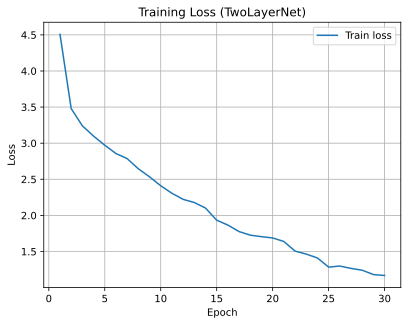

<Figure size 640x480 with 0 Axes>

In [39]:
# Plot losses
plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (TwoLayerNet)")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("2layers_loss_lr05.svg", format="svg", bbox_inches="tight")


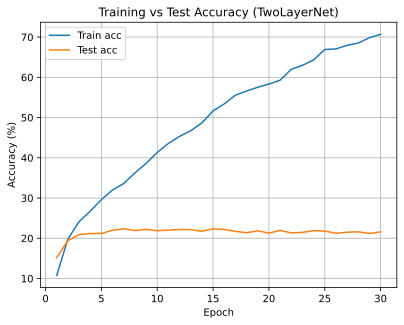

<Figure size 640x480 with 0 Axes>

In [40]:
# Optional: plot accuracies too
plt.figure()
plt.plot(range(1, len(train_accs)+1), train_accs, label="Train acc")
plt.plot(range(1, len(test_accs)+1),  test_accs,  label="Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy (TwoLayerNet)")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("2layers_accs_lr05.svg", format="svg", bbox_inches="tight")

In [41]:
### count number of trainable parameters
model_name = "TwoLayerNet"  # or "TwoLayerNet"

model_eval = twolayer 

num_params = sum(p.numel() for p in model_eval.parameters() if p.requires_grad)
print(f"\n Model selected: {model_name}")
print(f" Trainable parameters: {num_params:,}\n")


 Model selected: TwoLayerNet
 Trainable parameters: 1,624,676



Finally, train the ConvNet model on the CIFAR-100 dataset using the training data loader.

In [42]:

# ConvNet - baseline model

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
convnet = ConvNet(num_classes=100).to(device)

# Optimizer: use the function defined before
optimizer_cnn = create_optimizer(convnet, learning_rate=lr)

# Loss function
criterion = nn.CrossEntropyLoss()

# Train ConvNet model
convnet, train_losses_c, train_accs_c, test_accs_c = train(convnet, train_loader, test_loader, criterion, optimizer_cnn, epochs, device=device)

# Save weights + full model
Path("checkpoints").mkdir(parents=True, exist_ok=True)
torch.save(convnet.state_dict(), "checkpoints/convnet_weights.pth")
torch.save(convnet,            "checkpoints/convnet_model.pth")
print("[SAVE] ConvNet -> checkpoints/convnet_weights.pth & convnet_model.pth")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-13
Accuracy of the network on the test images: 12.68 %
Epoch 001/30 | train_loss=4.1029 train_acc=8.16%  test_acc=12.68%  
Accuracy of the network on the test images: 16.58 %
Epoch 002/30 | train_loss=3.6660 train_acc=14.96%  test_acc=16.58%  
Accuracy of the network on the test images: 18.83 %
Epoch 003/30 | train_loss=3.4599 train_acc=18.32%  test_acc=18.83%  
Accuracy of the network on the test images: 20.59 %
Epoch 004/30 | train_loss=3.3133 train_acc=20.94%  test_acc=20.59%  
Accuracy of the network on the test images: 21.72 %
Epoch 005/30 | train_loss=3.2058 train_acc=22.74%  test_acc=21.72%  
Accuracy of the network on the test images: 22.81 %
Epoch 006/30 | train_loss=3.1121 train_acc=24.47%  test_acc=22.81%  
Accuracy of the network on the test images: 23.26 %
Epoch 007/30 | train_loss=3.0521 train_acc=25.57%  test_acc=23.26

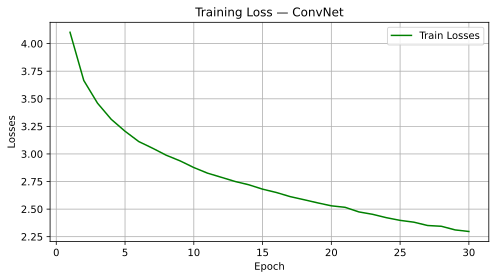

<Figure size 640x480 with 0 Axes>

In [43]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(train_losses_c)+1)

plt.figure(figsize=(7,4))
plt.plot(epochs, train_losses_c, label='Train Losses', color='green')
plt.title("Training Loss — ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Losses")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("ConnNet_loss1.svg", format="svg", bbox_inches="tight")

_____________

Some plots to compare the performance of the models
___________________


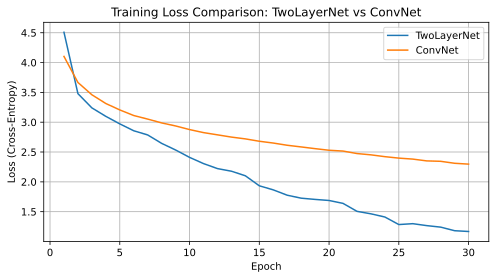

<Figure size 640x480 with 0 Axes>

In [44]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(train_losses)+1), train_losses, label='TwoLayerNet')
plt.plot(np.arange(1, len(train_losses_c)+1), train_losses_c, label='ConvNet')
plt.title("Training Loss Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("2layers_ConvNet_loss1.svg", format="svg", bbox_inches="tight")

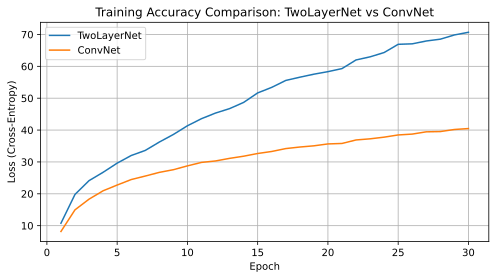

<Figure size 640x480 with 0 Axes>

In [45]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(train_accs)+1), train_accs, label='TwoLayerNet')
plt.plot(np.arange(1, len(train_accs_c)+1), train_accs_c, label='ConvNet')
plt.title("Training Accuracy Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("2layers_ConvNet_accs1.svg", format="svg", bbox_inches="tight")

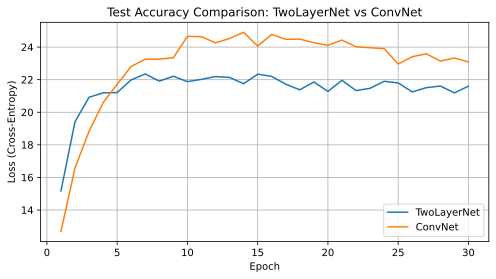

<Figure size 640x480 with 0 Axes>

In [46]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(test_accs)+1), test_accs, label='TwoLayerNet')
plt.plot(np.arange(1, len(test_accs_c)+1), test_accs_c, label='ConvNet')
plt.title("Test Accuracy Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("2layers_ConvNet_test_accs1.svg", format="svg", bbox_inches="tight")

In [47]:
## Count the n umber of trainable parameters

model_name = "ConvNet"  
model_eval = convnet 

num_params = sum(p.numel() for p in model_eval.parameters() if p.requires_grad)
print(f"\n Model selected: {model_name}")
print(f" Trainable parameters: {num_params:,}\n")



 Model selected: ConvNet
 Trainable parameters: 69,656



<a id="section-7"></a>
### **Section 7: Setting Up the Hyperparameters (14 points)**

In this section, you will experiment with both the `ConvNet` and `TwoLayerNet` models by setting up and tuning the hyperparameters to achieve the highest possible accuracy. You have the flexibility to modify the training process, including the `train` function, `DataLoader`, `transform` functions, and optimizer as needed.

1. Adjust the hyperparameters, including learning rate, batch size, number of epochs, optimizer, weight decay, and transform function to improve the performance of both networks. Modify the training procedure and architecture as necessary. You can also add components like Batch Normalization layers.
2. Add two more layers to both `TwoLayerNet` and `ConvNet`. You can decide the size and placement of these layers. Evaluate if these changes result in higher performance and explain your findings.
3. Show the final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both `TwoLayerNet` and `ConvNet`.
4. Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

**Note:** Do not use external pre-trained networks and limit additional convolutional layers to a maximum of three beyond the original architecture.

______________________

## Question 7.1. Hyperparameter tuning

______________

- Simple Grid Search
- Simple Random Search
- Optuna

In [49]:

num_classes = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()

# original datasets
base_train_ds = train_loader.dataset
base_test_ds  = test_loader.dataset

#  choose model and optimizer 
def make_model(name):
    if name.lower() == "twolayernet":
        return TwoLayerNet(3*32*32, 512, num_classes).to(device)
    return ConvNet(num_classes=num_classes).to(device)

def make_optimizer(model, name, lr, wd):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    if name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    # fallback if you have a factory
    try:
        return create_optimizer(model, learning_rate=lr)
    except Exception:
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)

## loss function
criterion = nn.CrossEntropyLoss()

# define grid 
grid = [
    # model,       opt,     lr,      wd,    epochs,  batch_size
    ("TwoLayerNet","sgd",   0.005,   5e-4,  10,      1024),
    ("TwoLayerNet","adamw", 0.001,   1e-4,  10,      1024),
    ("TwoLayerNet","adamw", 0.0001,  1e-4,  10,      512),
    ("TwoLayerNet","sgd",   0.05,    1e-4,  10,      512),
    ("ConvNet",    "sgd",   0.05,    5e-4,  10,      256),
    ("ConvNet",    "adamw", 0.001,   1e-4,  10,      256),
    ("ConvNet",    "sgd",   0.005,   1e-4,  10,      128),  
    ("ConvNet",    "adamw", 0.001,   1e-4,  10,      128),
]

# run grid and track best weights per model 
Path("artifacts/tuning/grid").mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
best_tln_score, best_cnn_score = -1.0, -1.0
best_tln_path = f"artifacts/tuning/grid/best_TwoLayerNet_{run_id}.pt"
best_cnn_path = f"artifacts/tuning/grid/best_ConvNet_{run_id}.pt"

results = []
for mname, oname, lr, wd, epochs, bs in grid:
    # rebuild loaders for this batch size
    tr_loader = DataLoader(base_train_ds, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=pin)
    te_loader = DataLoader(base_test_ds,  batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)

    model = make_model(mname)
    opt   = make_optimizer(model, oname, lr, wd)

    out = train(model, tr_loader, te_loader, criterion, opt, epochs=epochs, device=device)

    # Accept (model, tr_losses, tr_accs, te_losses, te_accs) or (model, tr_losses, tr_accs, te_accs)
    if len(out) == 5:
        trained_model, tr_losses, tr_accs, te_losses, te_accs = out
    else:
        trained_model, tr_losses, tr_accs, te_accs = out
        te_losses = []

    final = te_accs[-1] if te_accs else float("nan")
    best_acc = max(te_accs) if te_accs else float("nan")
    print(f"[{mname} | {oname}] final={final:.2f}% best={best_acc:.2f}%")

    # save best weights per model when improved
    if mname.lower() == "twolayernet" and (best_tln_score < best_acc):
        best_tln_score = best_acc
        torch.save(trained_model.state_dict(), best_tln_path)
    if mname.lower() == "convnet" and (best_cnn_score < best_acc):
        best_cnn_score = best_acc
        torch.save(trained_model.state_dict(), best_cnn_path)

    results.append({
        "model": mname, "opt": oname, "lr": lr, "wd": wd, "epochs": epochs, "bs": bs,
        "final": final, "best": best_acc
    })

# save best hyperparameters to CSVs 
df = pd.DataFrame(results)
df.to_csv(f"artifacts/tuning/grid/all_trials_{run_id}.csv", index=False)

best = df.loc[df.groupby("model")["best"].idxmax()].reset_index(drop=True)
best.to_csv(f"artifacts/tuning/grid/best_per_model_{run_id}.csv", index=False)

print("\n[Winners per model]")
print(best[["model","best","opt","lr","wd","epochs","bs"]])

print("\n[Saved best weights]")
print(f"TwoLayerNet -> {best_tln_path}  (best={best_tln_score:.2f}%)")
print(f"ConvNet     -> {best_cnn_path}  (best={best_cnn_score:.2f}%)")


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 5.69 %
Epoch 001/10 | train_loss=4.5184 train_acc=3.85%  test_acc=5.69%  
Accuracy of the network on the test images: 8.06 %
Epoch 002/10 | train_loss=4.2928 train_acc=6.96%  test_acc=8.06%  
Accuracy of the network on the test images: 9.95 %
Epoch 003/10 | train_loss=4.1079 train_acc=9.39%  test_acc=9.95%  
Accuracy of the network on the test images: 11.42 %
Epoch 004/10 | train_loss=3.9773 train_acc=11.11%  test_acc=11.42%  
Accuracy of the network on the test images: 12.34 %
Epoch 005/10 | train_loss=3.8838 train_acc=12.48%  test_acc=12.34%  
Accuracy of the network on the test images: 13.28 %
Epoch 006/10 | train_loss=3.8122 train_acc=13.60%  test_acc=13.28%  
Accuracy of the network on the test images: 14.23 %
Epoch 007/10 | train_loss=3.7533 train_acc=14.66%  test_acc=14.23%  


______________________
Hyperparameter tuning using a simple Random Search
_______________________

In [19]:
### Hyperparameter tuning using a simple random search

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
rng = random.Random(42)
NUM_CLASSES = 100

# original datasets
base_train_ds = train_loader.dataset
base_test_ds  = test_loader.dataset

# validation set
def make_val_split(base_train_loader, batch_size, val_split=0.1):
    ds = base_train_loader.dataset
    n_val = int(val_split * len(ds))
    tr_ds, va_ds = random_split(ds, [len(ds)-n_val, n_val],
                                generator=torch.Generator().manual_seed(123))
    tr = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=pin)
    va = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    return tr, va

# choose optimizer
def make_optimizer(params, name, lr, wd, momentum=0.9):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=momentum, nesterov=(momentum > 0),
                               dampening=0.0, weight_decay=wd)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=wd)
    return torch.optim.AdamW(params, lr=lr, weight_decay=wd)

def log_uniform(lo, hi):
    return 10 ** rng.uniform(math.log10(lo), math.log10(hi))

# run model and returns metrics
def run_train(model, tr_loader, va_loader, epochs, lr, wd, opt_name, momentum=0.9):
    opt  = make_optimizer(model.parameters(), opt_name, lr, wd, momentum)
    crit = nn.CrossEntropyLoss()
    out  = train(model, tr_loader, va_loader, crit, opt, epochs=epochs, device=device)
    te_accs = out[-1] if len(out) == 5 else out[3]  # support both signatures
    return float(te_accs[-1]), float(max(te_accs))

# search spaces and number of trials
N_TRIALS_TLN = 10
N_TRIALS_CNN = 10
BS_CHOICES    = [256, 512] if pin else [128, 256]
OPT_CHOICES   = ["sgd", "adamw"]

# results and best-weight 
rows = []

Path("artifacts/tuning/RS").mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
best_tln_score, best_cnn_score = -1.0, -1.0
best_tln_path = f"artifacts/tuning/RS/best_TwoLayerNet_{run_id}.pt"
best_cnn_path = f"artifacts/tuning/RS/best_ConvNet_{run_id}.pt"

# Random Search for TwoLayerNet model
best_tln = {"score": -1.0, "cfg": None}
for t in range(N_TRIALS_TLN):
    lr   = log_uniform(1e-4, 5e-1)
    wd   = log_uniform(1e-6, 5e-3)
    optn = rng.choice(OPT_CHOICES)
    mom  = rng.uniform(0.80, 0.99) if optn == "sgd" else 0.0
    bs   = rng.choice(BS_CHOICES)
    hid  = rng.choice([512, 768, 1024])
    ep   = rng.randint(6, 12)

    tr, va = make_val_split(train_loader, bs)
    model  = TwoLayerNet(3*32*32, hid, NUM_CLASSES).to(device)

    final, best = run_train(model, tr, va, ep, lr, wd, optn, mom)
    print(f"[TLN {t+1}/{N_TRIALS_TLN}] final={final:.2f}% best={best:.2f}% | "
          f"opt={optn} lr={lr:.4g} wd={wd:.2g} mom={mom:.2f} bs={bs} hid={hid} ep={ep}")

    
    if best > best_tln_score:
        best_tln_score = best
        torch.save(model.state_dict(), best_tln_path)

    rows.append({
        "model":"TwoLayerNet","final":final,"best":best,"optimizer":optn,"lr":lr,
        "weight_decay":wd,"momentum":mom,"batch_size":bs,"hidden_size":hid,"epochs":ep
    })

    if best > best_tln["score"]:
        best_tln = {"score": best, "cfg": dict(model="TwoLayerNet", lr=lr, weight_decay=wd,
                                               optimizer=optn, momentum=mom, batch_size=bs,
                                               hidden_size=hid, epochs=ep)}

print("\n[TwoLayerNet] Best:", best_tln["score"], "\nParams:", json.dumps(best_tln["cfg"], indent=2))

# Random Search for ConvNet model
best_cnn = {"score": -1.0, "cfg": None}
for t in range(N_TRIALS_CNN):
    lr   = log_uniform(1e-4, 5e-1)
    wd   = log_uniform(1e-6, 5e-3)
    optn = rng.choice(OPT_CHOICES)
    mom  = rng.uniform(0.80, 0.99) if optn == "sgd" else 0.0
    bs   = rng.choice(BS_CHOICES)
    ep   = rng.randint(6, 12)
    dropout = rng.uniform(0.0, 0.5)
    widen   = rng.choice([1, 2])

    tr, va = make_val_split(train_loader, bs)
    try:
        model = ConvNet(num_classes=NUM_CLASSES, dropout=dropout, widen=widen).to(device)
    except TypeError:
        model = ConvNet(num_classes=NUM_CLASSES).to(device)

    final, best = run_train(model, tr, va, ep, lr, wd, optn, mom)
    print(f"[CNN {t+1}/{N_TRIALS_CNN}] final={final:.2f}% best={best:.2f}% | "
          f"opt={optn} lr={lr:.4g} wd={wd:.2g} mom={mom:.2f} bs={bs} ep={ep} drop={dropout:.2f} widen={widen}")

    # Save best weights for CNN if improved
    if best > best_cnn_score:
        best_cnn_score = best
        torch.save(model.state_dict(), best_cnn_path)

    rows.append({
        "model":"ConvNet","final":final,"best":best,"optimizer":optn,"lr":lr,
        "weight_decay":wd,"momentum":mom,"batch_size":bs,"epochs":ep,
        "dropout":dropout,"widen":widen
    })

    if best > best_cnn["score"]:
        best_cnn = {"score": best, "cfg": dict(model="ConvNet", lr=lr, weight_decay=wd,
                                               optimizer=optn, momentum=mom, batch_size=bs,
                                               epochs=ep, dropout=dropout, widen=widen)}

print("\n[ConvNet] Best:", best_cnn["score"], "\nParams:", json.dumps(best_cnn["cfg"], indent=2))

# Save best results to CSVs files
df = pd.DataFrame(rows)
df.to_csv(f"artifacts/tuning/RS/random_search_all_{run_id}.csv", index=False)

best_per_model = df.loc[df.groupby("model")["best"].idxmax()].reset_index(drop=True)
best_per_model.to_csv(f"artifacts/tuning/RS/random_search_best_per_model_{run_id}.csv", index=False)

print("\n[Winners]")
print(best_per_model[["model","best","optimizer","lr","weight_decay","momentum","batch_size","epochs"] +
                     [c for c in ["hidden_size","dropout","widen"] if c in best_per_model.columns]])

print("\n[Saved best weights]")
print(f"TwoLayerNet -> {best_tln_path}  (best={best_tln_score:.2f}%)")
print(f"ConvNet     -> {best_cnn_path}  (best={best_cnn_score:.2f}%)")


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 4.72 %
Epoch 001/7 | train_loss=34.8174 train_acc=3.68%  test_acc=4.72%  
Accuracy of the network on the test images: 4.44 %
Epoch 002/7 | train_loss=20.8331 train_acc=5.34%  test_acc=4.44%  
Accuracy of the network on the test images: 4.68 %
Epoch 003/7 | train_loss=18.4286 train_acc=5.69%  test_acc=4.68%  
Accuracy of the network on the test images: 4.58 %
Epoch 004/7 | train_loss=18.3434 train_acc=5.84%  test_acc=4.58%  
Accuracy of the network on the test images: 5.46 %
Epoch 005/7 | train_loss=16.9472 train_acc=6.08%  test_acc=5.46%  
Accuracy of the network on the test images: 4.50 %
Epoch 006/7 | train_loss=18.4612 train_acc=5.86%  test_acc=4.50%  
Accuracy of the network on the test images: 4.44 %
Epoch 007/7 | train_loss=16.0112 train_acc=5.98%  test_acc=4.44%  
[TLN 1/10] f

________________
 Hyperparameter tuning using Optuna
 _____________

In [20]:
### Optuna tuning for TwoLayerNet & ConvNet with best-weight saving

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
NUM_CLASSES = 100
BATCH_SIZE  = 512 if pin else 256
EPOCHS      = 10

# output directory and run id
out_dir = Path("artifacts/optuna")
out_dir.mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
best_tln_path = out_dir / f"best_TwoLayerNet_{run_id}.pt"
best_cnn_path = out_dir / f"best_ConvNet_{run_id}.pt"

# global trackers for best weights
best_tln_score = -1.0
best_cnn_score = -1.0

def _val_split(base_loader, bs=BATCH_SIZE, val_frac=0.1):
    ds = base_loader.dataset
    n_val = int(len(ds) * val_frac)
    tr_ds, va_ds = random_split(
        ds, [len(ds)-n_val, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    tr = DataLoader(tr_ds, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=pin)
    va = DataLoader(va_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)
    return tr, va

def _make_opt(params, name, lr, wd, momentum=0.9):
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=momentum, nesterov=True, weight_decay=wd)
    return torch.optim.AdamW(params, lr=lr, weight_decay=wd)

def _run_trial(model, tr_loader, va_loader, lr, wd, opt_name, epochs=EPOCHS):
    opt  = _make_opt(model.parameters(), opt_name, lr, wd)
    crit = nn.CrossEntropyLoss()
    out  = train(model, tr_loader, va_loader, crit, opt, epochs=epochs, device=device)
    te_accs = out[-1] if len(out) == 5 else out[3]   # supports both return signatures
    return float(te_accs[-1]), float(max(te_accs))

# objective
def objective_twolayer(trial):
    global best_tln_score
    lr   = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    wd   = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optn = trial.suggest_categorical("optimizer", ["sgd", "adamw"])
    hid  = trial.suggest_categorical("hidden_size", [256, 512, 768, 1024])

    tr, va = _val_split(train_loader, BATCH_SIZE)
    model  = TwoLayerNet(3*32*32, hid, NUM_CLASSES).to(device)

    final_acc, best_acc = _run_trial(model, tr, va, lr, wd, optn, EPOCHS)
    trial.set_user_attr("final", final_acc)

    # save weights if new best
    if best_acc > best_tln_score:
        best_tln_score = best_acc
        torch.save(model.state_dict(), best_tln_path)

    return best_acc

def objective_convnet(trial):
    global best_cnn_score
    lr   = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    wd   = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optn = trial.suggest_categorical("optimizer", ["sgd", "adamw"])
    

    tr, va = _val_split(train_loader, BATCH_SIZE)
    try:
        model = ConvNet(num_classes=NUM_CLASSES).to(device)
    except TypeError:
        model = ConvNet().to(device)

    final_acc, best_acc = _run_trial(model, tr, va, lr, wd, optn, EPOCHS)
    trial.set_user_attr("final", final_acc)

    if best_acc > best_cnn_score:
        best_cnn_score = best_acc
        torch.save(model.state_dict(), best_cnn_path)

    return best_acc

# Run trials
N_TRIALS = 10
study_tln = optuna.create_study(direction="maximize", study_name="TwoLayerNet")
study_tln.optimize(objective_twolayer, n_trials=N_TRIALS, show_progress_bar=False)

study_cnn = optuna.create_study(direction="maximize", study_name="ConvNet")
study_cnn.optimize(objective_convnet, n_trials=N_TRIALS, show_progress_bar=False)

# Save trials to tables 
df_tln = study_tln.trials_dataframe(attrs=("number","value","params","state","user_attrs"))
df_cnn = study_cnn.trials_dataframe(attrs=("number","value","params","state","user_attrs"))
df_tln.to_csv(out_dir / f"twolayernet_trials_{run_id}.csv", index=False)
df_cnn.to_csv(out_dir / f"convnet_trials_{run_id}.csv",    index=False)

# Save the best parameters to CSV file
best_tln = {"model":"TwoLayerNet", "best_value": study_tln.best_value, **study_tln.best_params}
best_cnn = {"model":"ConvNet",     "best_value": study_cnn.best_value, **study_cnn.best_params}
pd.DataFrame([best_tln, best_cnn]).to_csv(out_dir / f"best_params_{run_id}.csv", index=False)

# Print summary and info about weights location
print("\n[TwoLayerNet] best value:", study_tln.best_value)
print("[TwoLayerNet] best params:", json.dumps(study_tln.best_params, indent=2))
print("\n[ConvNet]    best value:", study_cnn.best_value)
print("[ConvNet]    best params:", json.dumps(study_cnn.best_params, indent=2))

print("\n[Saved best weights]")
print(f"TwoLayerNet -> {best_tln_path}  (best={best_tln_score:.2f}%)")
print(f"ConvNet     -> {best_cnn_path}  (best={best_cnn_score:.2f}%)")


[I 2025-10-13 21:12:19,523] A new study created in memory with name: TwoLayerNet


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 4.14 %
Epoch 001/10 | train_loss=89.6032 train_acc=2.77%  test_acc=4.14%  
Accuracy of the network on the test images: 4.38 %
Epoch 002/10 | train_loss=56.6909 train_acc=4.62%  test_acc=4.38%  
Accuracy of the network on the test images: 5.22 %
Epoch 003/10 | train_loss=33.7252 train_acc=5.35%  test_acc=5.22%  
Accuracy of the network on the test images: 5.28 %
Epoch 004/10 | train_loss=26.6370 train_acc=5.81%  test_acc=5.28%  
Accuracy of the network on the test images: 5.58 %
Epoch 005/10 | train_loss=23.0609 train_acc=5.93%  test_acc=5.58%  
Accuracy of the network on the test images: 4.76 %
Epoch 006/10 | train_loss=14.2650 train_acc=7.15%  test_acc=4.76%  
Accuracy of the network on the test images: 5.92 %
Epoch 007/10 | train_loss=11.2319 train_acc=8.17%  test_acc=5.92%  
Accur

[I 2025-10-13 21:13:05,351] Trial 0 finished with value: 7.9 and parameters: {'lr': 0.035245983576618456, 'weight_decay': 0.0007109980192170889, 'optimizer': 'adamw', 'hidden_size': 512}. Best is trial 0 with value: 7.9.


Accuracy of the network on the test images: 7.74 %
Epoch 010/10 | train_loss=7.4192 train_acc=10.84%  test_acc=7.74%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-13
Accuracy of the network on the test images: 13.48 %
Epoch 001/10 | train_loss=4.1560 train_acc=8.28%  test_acc=13.48%  
Accuracy of the network on the test images: 17.74 %
Epoch 002/10 | train_loss=3.6711 train_acc=15.51%  test_acc=17.74%  
Accuracy of the network on the test images: 19.00 %
Epoch 003/10 | train_loss=3.4912 train_acc=18.78%  test_acc=19.00%  
Accuracy of the network on the test images: 20.66 %
Epoch 004/10 | train_loss=3.3759 train_acc=20.69%  test_acc=20.66%  
Accuracy of the network on the test images: 21.68 %
Epoch 005/10 | train_loss=3.2817 train_acc=22.62%  test_acc=21.68%  
Accuracy of the network on the test images: 22.22 %
Epoch 006/10 | train_loss=3.2004 train_acc=24.20%  test_acc=22.

[I 2025-10-13 21:13:49,602] Trial 1 finished with value: 24.26 and parameters: {'lr': 0.019083652032634804, 'weight_decay': 3.947805350777423e-05, 'optimizer': 'sgd', 'hidden_size': 512}. Best is trial 1 with value: 24.26.


...

Accuracy of the network on the test images: 11.68 %
Epoch 010/10 | train_loss=3.8530 train_acc=11.40%  test_acc=11.68%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-13
Accuracy of the network on the test images: 0.82 %
Epoch 001/10 | train_loss=4.6072 train_acc=0.76%  test_acc=0.82%  
Accuracy of the network on the test images: 0.82 %
Epoch 002/10 | train_loss=4.6070 train_acc=0.76%  test_acc=0.82%  
Accuracy of the network on the test images: 0.82 %
Epoch 003/10 | train_loss=4.6067 train_acc=0.78%  test_acc=0.82%  
Accuracy of the network on the test images: 0.86 %
Epoch 004/10 | train_loss=4.6065 train_acc=0.78%  test_acc=0.86%  
Accuracy of the network on the test images: 0.84 %
Epoch 005/10 | train_loss=4.6062 train_acc=0.78%  test_acc=0.84%  
Accuracy of the network on the test images: 0.86 %
Epoch 006/10 | train_loss=4.6060 train_acc=0.79%  test_acc=0.86%  
Accuracy of t

[I 2025-10-13 21:41:18,236] Trial 8 finished with value: 0.86 and parameters: {'lr': 0.0001308299811402797, 'weight_decay': 3.2346606869550686e-06, 'optimizer': 'sgd'}. Best is trial 2 with value: 23.72.


Accuracy of the network on the test images: 0.84 %
Epoch 010/10 | train_loss=4.6049 train_acc=0.83%  test_acc=0.84%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-13
Accuracy of the network on the test images: 0.80 %
Epoch 001/10 | train_loss=4.6073 train_acc=0.80%  test_acc=0.80%  
Accuracy of the network on the test images: 0.90 %
Epoch 002/10 | train_loss=4.6048 train_acc=0.91%  test_acc=0.90%  
Accuracy of the network on the test images: 1.08 %
Epoch 003/10 | train_loss=4.6014 train_acc=1.07%  test_acc=1.08%  
Accuracy of the network on the test images: 1.66 %
Epoch 004/10 | train_loss=4.5957 train_acc=1.43%  test_acc=1.66%  
Accuracy of the network on the test images: 2.38 %
Epoch 005/10 | train_loss=4.5857 train_acc=1.97%  test_acc=2.38%  
Accuracy of the network on the test images: 3.20 %
Epoch 006/10 | train_loss=4.5699 train_acc=2.59%  test_acc=3.20%  
Accuracy of the 

[I 2025-10-13 21:43:17,642] Trial 9 finished with value: 5.14 and parameters: {'lr': 0.001728042789556322, 'weight_decay': 1.788333859586217e-05, 'optimizer': 'sgd'}. Best is trial 2 with value: 23.72.


Accuracy of the network on the test images: 5.14 %
Epoch 010/10 | train_loss=4.4546 train_acc=4.44%  test_acc=5.14%  

[TwoLayerNet] best value: 25.12
[TwoLayerNet] best params: {
  "lr": 0.032204917005666564,
  "weight_decay": 0.00013486959005032446,
  "optimizer": "sgd",
  "hidden_size": 768
}

[ConvNet]    best value: 23.72
[ConvNet]    best params: {
  "lr": 0.001735448252398407,
  "weight_decay": 7.423511923125965e-05,
  "optimizer": "adamw"
}

[Saved best weights]
TwoLayerNet -> artifacts\optuna\best_TwoLayerNet_20251013-211219.pt  (best=25.12%)
ConvNet     -> artifacts\optuna\best_ConvNet_20251013-211219.pt  (best=23.72%)


______________________

## Question 7.2. TwoLayerNet and ConvNet with more two layers

_____________________

- TwoLayerNet
    - version 1: add two more fully connected hidden layers
    - version 2: add two more fully connected hidden layers with BatchNormalization and DropOut 

In [25]:
### new TwoLayerNet - version 1 - with two new hidden layers
## we keep the same activation function (ReLU)

class TwoLayerNetPlus(nn.Module):
    """
    A deeper MLP: input -> h1 -> h2 -> h3 -> logits
    
    """
    def __init__(self, input_size: int, hidden1: int, hidden2: int, hidden3: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1), nn.ReLU(),  ## original first layer
            nn.Linear(hidden1, hidden2),   nn.ReLU(),   # add 1 hidden layer (fully connected)
            nn.Linear(hidden2, hidden3),   nn.ReLU(),   # add 1 hidden layer (fully connected)
            nn.Linear(hidden3, num_classes)             # original final layer
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Flatten to (batch, features) then pass through the MLP
        return self.net(x.flatten(1))


In [26]:
### TwoLayerNet - version 2 - with two new hidden layers with BatchNorm and Dropout
## we keep the same activation function (ReLU)

class TwoLayerNetBNDrop(nn.Module):
    """
    Keeps the original layers:
      Linear(input -> hidden) -> ReLU
      Linear(hidden -> num_classes)
    and INSERTS two new hidden layers (hidden -> hidden) with BatchNorm and Dropout in between.
    """
    def __init__(self, input_size: int, hidden: int, num_classes: int, p: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            # original first layer
            nn.Linear(input_size, hidden), nn.ReLU(inplace=True),

            # New layer #1 (hidden -> hidden) 
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # New layer #2 (hidden -> hidden)
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # original final layer (kept intact: hidden -> num_classes) ---
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.flatten(1))


________________________
- ConvNet
    - version 1: add two convolutional layers
    - version 2: add two more fully connected hidden layers with BatchNormalization and DropOut

__________________________

In [27]:
### New ConvNet - version 1
# In the first block add two new convolutional layers 
# we keep the same activation function and Pooling: Tanh + AvgPool

class ConvNet_ExtraConv(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        # Feature extractor: +2 conv layers at 5×5 stage (preserve spatial size with padding=1)
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),   nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 32->14

            nn.Conv2d(6, 16, 5),  nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 14->5

            # + New conv layer 1 (keeps 5x5)
            nn.Conv2d(16, 32, 3, padding=1), nn.Tanh(),
            # + New conv layer 2 (keeps 5x5)
            nn.Conv2d(32, 32, 3, padding=1), nn.Tanh(),

            # Final conv to 1x1
            nn.Conv2d(32, 120, 5), nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(256), nn.Tanh(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [28]:
### New ConvNet - version 2
# Add two fully connected layers in the classifier block
# we keep the same activation function (Tanh):

class ConvNet_ExtraFC(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),   nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 32->14

            nn.Conv2d(6, 16, 5),  nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 14->5

            nn.Conv2d(16, 120, 5), nn.Tanh()  # -> 1x1
        )

        # Classifier: +2 extra FC layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 256), nn.Tanh(),   # +1
            nn.Linear(256, 128), nn.Tanh(),   # +2
            nn.Linear(128, 84),  nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)



In [29]:
### New ConvNet - version 3
## - keep first two conv+pool blocks 
## - after the second pool (spatial = 5x5), insert 2 new convolutional layers
    ## - with padding=1 so spatial size stays 5x5
    ## - add BatchNorm and Dropout2d around the new convs
## - final 5x5 -> 1x1 projection updated to expect 32 channels

import torch
import torch.nn as nn

class ConvNetNew(nn.Module):
    def __init__(self, num_classes=100, p_drop=0.2):
        super().__init__()

        
        self.features = nn.Sequential(
            # Block 1: [3,32,32] -> [6,28,28] -> pool -> [6,14,14]
            nn.Conv2d(3, 6, 5),         # no padding (original)
            nn.Tanh(),
            nn.AvgPool2d(2, 2),

            # Block 2: [6,14,14] -> [16,10,10] -> pool -> [16,5,5]
            nn.Conv2d(6, 16, 5),        # no padding (original)
            nn.Tanh(),
            nn.AvgPool2d(2, 2),

            # 2 new layers (convolutional with padding, + BN/Dropout) 
            nn.Conv2d(16, 32, 3, padding=1),  
            nn.BatchNorm2d(32),
            nn.Tanh(),
            nn.Dropout2d(p_drop),

            nn.Conv2d(32, 32, 3, padding=1),  
            nn.BatchNorm2d(32),
            nn.Tanh(),
            # (no pool here; stay at 5x5)

            # Final projection to 1x1 (expect 32 now)
            nn.Conv2d(32, 120, 5),      # [32,5,5] -> [120,1,1]
            nn.Tanh()
        )

        # Classifier block remains unchanged
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [35]:
# Train TwoLayerNetPlus and augmented ConvNet, collect accuracies 
############### this is the best version combination ##########################

import torch, torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 30
NUM_CLASSES = 100

# Models
mlp = TwoLayerNetBNDrop(input_size=3*32*32, hidden=512, num_classes=NUM_CLASSES).to(device)
cnn = ConvNetNew(num_classes=NUM_CLASSES, p_drop=0.3).to(device)  # your augmented ConvNet class

# Optimizers (good defaults)
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True, weight_decay=5e-4)

# Loss 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train 
res_mlp = train(mlp, train_loader, test_loader, criterion, opt_mlp, epochs=EPOCHS, device=device)
res_cnn = train(cnn, train_loader, test_loader, criterion, opt_cnn, epochs=EPOCHS, device=device)

def unpack(res):
    if len(res) == 5:
        model, tr_losses, tr_accs, te_losses, te_accs = res
    else:
        model, tr_losses, tr_accs, te_accs = res
        te_losses = [float("nan")] * len(te_accs)
    return model, tr_losses, tr_accs, te_losses, te_accs

mlp_model, mlp_tr_loss, mlp_tr_acc, mlp_te_loss, mlp_te_acc = unpack(res_mlp)
cnn_model, cnn_tr_loss, cnn_tr_acc, cnn_te_loss, cnn_te_acc = unpack(res_cnn)

print(f"[TwoLayerNetBNDrop] final_test={mlp_te_acc[-1]:.2f}% | best_test={max(mlp_te_acc):.2f}%")
print(f"[ConvNetNew] final_test={cnn_te_acc[-1]:.2f}% | best_test={max(cnn_te_acc):.2f}%")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetBNDrop\2025-10-13
Accuracy of the network on the test images: 17.56 %
Epoch 001/30 | train_loss=3.9863 train_acc=12.02%  test_acc=17.56%  
Accuracy of the network on the test images: 21.72 %
Epoch 002/30 | train_loss=3.6334 train_acc=18.59%  test_acc=21.72%  
Accuracy of the network on the test images: 23.76 %
Epoch 003/30 | train_loss=3.4730 train_acc=22.42%  test_acc=23.76%  
Accuracy of the network on the test images: 25.20 %
Epoch 004/30 | train_loss=3.3580 train_acc=24.91%  test_acc=25.20%  
Accuracy of the network on the test images: 26.88 %
Epoch 005/30 | train_loss=3.2637 train_acc=27.39%  test_acc=26.88%  
Accuracy of the network on the test images: 27.88 %
Epoch 006/30 | train_loss=3.1856 train_acc=29.09%  test_acc=27.88%  
Accuracy of the network on the test images: 27.97 %
Epoch 007/30 | train_loss=3.0989 train_acc=31.37%  tes

In [37]:
### save results
rows = [
    {
        "model": "TwoLayerNetBNDrop",
        "final_train": float(mlp_tr_acc[-1]),
        "best_train":  float(max(mlp_tr_acc)),
        "final_test":  float(mlp_te_acc[-1]),
        "best_test":   float(max(mlp_te_acc)),
    },
    {
        "model": "ConvNetNew",
        "final_train": float(cnn_tr_acc[-1]),
        "best_train":  float(max(cnn_tr_acc)),
        "final_test":  float(cnn_te_acc[-1]),
        "best_test":   float(max(cnn_te_acc)),
    },
]

df = pd.DataFrame(rows)

Path("artifacts").mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
out_path = f"artifacts/final_best_with_train_{run_id}.csv"
df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(df)

Saved: artifacts/final_best_with_train_20251013-223243.csv
               model  final_train  best_train  final_test  best_test
0  TwoLayerNetBNDrop        68.56       68.56       29.88      31.04
1         ConvNetNew        35.48       35.48       29.58      30.73


Saved figure -> cifar100_acc_compare.svg


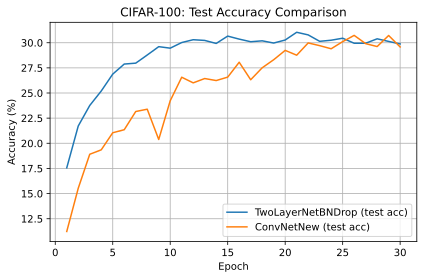

In [39]:
# Compare test accuracy across epochs and save figure
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_te_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, mlp_te_acc, label="TwoLayerNetBNDrop (test acc)")
plt.plot(epochs, cnn_te_acc, label="ConvNetNew (test acc)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100: Test Accuracy Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar100_acc_compare6.svg", format="svg", bbox_inches="tight")
print("Saved figure -> cifar100_acc_compare.svg")

In [47]:
# Train TwoLayerNetPlus and augmented ConvNet, collect accuracies## outros douis
import torch, torch.nn as nn

EPOCHS = 30
NUM_CLASSES = 100

# Models
mlp = TwoLayerNetBNDrop(input_size=3*32*32, hidden=512, num_classes=NUM_CLASSES).to(device)
cnn = ConvNet_ExtraFC(num_classes=NUM_CLASSES).to(device)  # your augmented ConvNet class

# Optimizers (good defaults)
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True, weight_decay=5e-4)

# Loss
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train 
res_mlp = train(mlp, train_loader, test_loader, criterion, opt_mlp, epochs=EPOCHS, device=device)
res_cnn = train(cnn, train_loader, test_loader, criterion, opt_cnn, epochs=EPOCHS, device=device)

def unpack(res):
    if len(res) == 5:
        model, tr_losses, tr_accs, te_losses, te_accs = res
    else:
        model, tr_losses, tr_accs, te_accs = res
        te_losses = [float("nan")] * len(te_accs)
    return model, tr_losses, tr_accs, te_losses, te_accs

mlp_model, mlp_tr_loss, mlp_tr_acc, mlp_te_loss, mlp_te_acc = unpack(res_mlp)
cnn_model, cnn_tr_loss, cnn_tr_acc, cnn_te_loss, cnn_te_acc = unpack(res_cnn)




print(f"[TwoLayerNetPlus] final_test={mlp_te_acc[-1]:.2f}% | best_test={max(mlp_te_acc):.2f}%")
print(f"[ConvNet(+2 layers)] final_test={cnn_te_acc[-1]:.2f}% | best_test={max(cnn_te_acc):.2f}%")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetBNDrop\2025-10-13
Accuracy of the network on the test images: 17.03 %
Epoch 001/30 | train_loss=4.0419 train_acc=10.83%  test_acc=17.03%  
Accuracy of the network on the test images: 21.71 %
Epoch 002/30 | train_loss=3.6736 train_acc=17.68%  test_acc=21.71%  
Accuracy of the network on the test images: 23.49 %
Epoch 003/30 | train_loss=3.5013 train_acc=21.70%  test_acc=23.49%  
Accuracy of the network on the test images: 25.12 %
Epoch 004/30 | train_loss=3.3826 train_acc=24.70%  test_acc=25.12%  
Accuracy of the network on the test images: 25.96 %
Epoch 005/30 | train_loss=3.2873 train_acc=26.95%  test_acc=25.96%  
Accuracy of the network on the test images: 27.19 %
Epoch 006/30 | train_loss=3.2005 train_acc=28.92%  test_acc=27.19%  
Accuracy of the network on the test images: 27.82 %
Epoch 007/30 | train_loss=3.1217 train_acc=31.11%  tes

In [48]:
rows = [
    {
        "model": "TwoLayerNetPlus",
        "final_train": float(mlp_tr_acc[-1]),
        "best_train":  float(max(mlp_tr_acc)),
        "final_test":  float(mlp_te_acc[-1]),
        "best_test":   float(max(mlp_te_acc)),
    },
    {
        "model": "ConvNet_ExtraConv(+2 layers)",
        "final_train": float(cnn_tr_acc[-1]),
        "best_train":  float(max(cnn_tr_acc)),
        "final_test":  float(cnn_te_acc[-1]),
        "best_test":   float(max(cnn_te_acc)),
    },
]

df = pd.DataFrame(rows)

Path("artifacts").mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
out_path = f"artifacts/final_best_with_train_{run_id}.csv"
df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(df)

Saved: artifacts/final_best_with_train_20251013-162625.csv
                          model  final_train  best_train  final_test  \
0               TwoLayerNetPlus       68.586      68.586       29.38   
1  ConvNet_ExtraConv(+2 layers)       30.978      30.978       25.39   

   best_test  
0      30.44  
1      25.59  


Saved figure -> cifar100_acc_compare3.svg


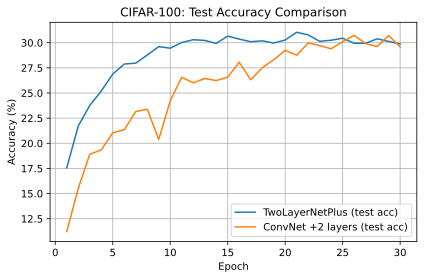

In [38]:
# Compare test accuracy across epochs and save figure
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_te_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, mlp_te_acc, label="TwoLayerNetPlus (test acc)")
plt.plot(epochs, cnn_te_acc, label="ConvNet +2 layers (test acc)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100: Test Accuracy Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar100_acc_compare2.svg", format="svg", bbox_inches="tight")
print("Saved figure -> cifar100_acc_compare3.svg")

In [52]:
# Train TwoLayerNetPlus and augmented ConvNet, collect accuracies
import torch, torch.nn as nn

EPOCHS = 30
NUM_CLASSES = 100

# Models
mlp = TwoLayerNetPlus(input_size=3*32*32, hidden1=512, hidden2=256, hidden3=256, num_classes=NUM_CLASSES).to(device)
cnn = ConvNet_ExtraConv(num_classes=NUM_CLASSES).to(device)  # your augmented ConvNet class

# Optimizers 
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
opt_cnn = torch.optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, nesterov=True, weight_decay=5e-4)

# Loss 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train 
res_mlp = train(mlp, train_loader, test_loader, criterion, opt_mlp, epochs=EPOCHS, device=device)
res_cnn = train(cnn, train_loader, test_loader, criterion, opt_cnn, epochs=EPOCHS, device=device)

def unpack(res):
    if len(res) == 5:
        model, tr_losses, tr_accs, te_losses, te_accs = res
    else:
        model, tr_losses, tr_accs, te_accs = res
        te_losses = [float("nan")] * len(te_accs)
    return model, tr_losses, tr_accs, te_losses, te_accs

mlp_model, mlp_tr_loss, mlp_tr_acc, mlp_te_loss, mlp_te_acc = unpack(res_mlp)
cnn_model, cnn_tr_loss, cnn_tr_acc, cnn_te_loss, cnn_te_acc = unpack(res_cnn)

print(f"[TwoLayerNetPlus] final_test={mlp_te_acc[-1]:.2f}% | best_test={max(mlp_te_acc):.2f}%")
print(f"[ConvNet_ExtraConv(+2 layers)] final_test={cnn_te_acc[-1]:.2f}% | best_test={max(cnn_te_acc):.2f}%")


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-lab-final\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNetPlus\2025-10-13
Accuracy of the network on the test images: 15.91 %
Epoch 001/30 | train_loss=4.0355 train_acc=10.97%  test_acc=15.91%  
Accuracy of the network on the test images: 19.94 %
Epoch 002/30 | train_loss=3.6567 train_acc=18.74%  test_acc=19.94%  
Accuracy of the network on the test images: 22.04 %
Epoch 003/30 | train_loss=3.4736 train_acc=23.11%  test_acc=22.04%  
Accuracy of the network on the test images: 23.75 %
Epoch 004/30 | train_loss=3.3374 train_acc=26.35%  test_acc=23.75%  
Accuracy of the network on the test images: 25.03 %
Epoch 005/30 | train_loss=3.2196 train_acc=29.15%  test_acc=25.03%  
Accuracy of the network on the test images: 26.10 %
Epoch 006/30 | train_loss=3.1046 train_acc=31.80%  test_acc=26.10%  
Accuracy of the network on the test images: 26.31 %
Epoch 007/30 | train_loss=2.9907 train_acc=34.90%  test_

In [53]:
rows = [
    {
        "model": "TwoLayerNetPlus",
        "final_train": float(mlp_tr_acc[-1]),
        "best_train":  float(max(mlp_tr_acc)),
        "final_test":  float(mlp_te_acc[-1]),
        "best_test":   float(max(mlp_te_acc)),
    },
    {
        "model": "ConvNet_ExtraConv(+2 layers)",
        "final_train": float(cnn_tr_acc[-1]),
        "best_train":  float(max(cnn_tr_acc)),
        "final_test":  float(cnn_te_acc[-1]),
        "best_test":   float(max(cnn_te_acc)),
    },
]

df = pd.DataFrame(rows)

Path("artifacts").mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
out_path = f"artifacts/final_best_with_train_{run_id}.csv"
df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(df)

Saved: artifacts/final_best_with_train_20251013-170004.csv
                          model  final_train  best_train  final_test  \
0               TwoLayerNetPlus       92.602      92.602       25.28   
1  ConvNet_ExtraConv(+2 layers)       40.308      40.308       30.47   

   best_test  
0      28.03  
1      30.47  


Saved figure -> cifar100_acc_compare.svg


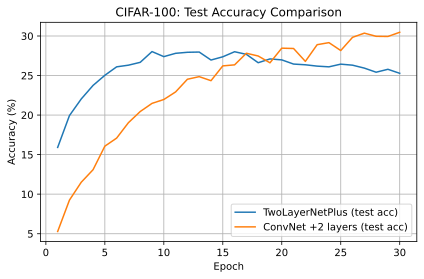

In [54]:
# Compare test accuracy across epochs and save figure
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_te_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, mlp_te_acc, label="TwoLayerNetPlus (test acc)")
plt.plot(epochs, cnn_te_acc, label="ConvNet +2 layers (test acc)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR-100: Test Accuracy Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cifar100_acc_compare.svg", format="svg", bbox_inches="tight")
print("Saved figure -> cifar100_acc_compare.svg")


__________________

## Question 7.3.
- Final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both TwoLayerNet and ConvNet

___________________

In [42]:
### visualize table with best accuracy and optimized hyperparameters

def latest_csv(globpat):
    files = sorted(Path().glob(globpat))
    assert files, f"No files found for pattern: {globpat}"
    return files[-1]

# Load the “best_per_model” produced by each search
df_grid   = pd.read_csv(latest_csv("artifacts/tuning/grid/best_per_model_*.csv"))
df_rand   = pd.read_csv(latest_csv("artifacts/tuning/RS/random_search_best_per_model_*.csv"))
df_optuna = pd.read_csv(latest_csv("artifacts/optuna/best_params.csv"))

# Merge and keep the best per model across all methods
df_all = pd.concat([df_grid, df_rand, df_optuna], ignore_index=True)
winners = df_all.sort_values(["model","best"], ascending=[True, False]).groupby("model", as_index=False).first()

cols = [c for c in ["model","best","final","optimizer","lr","weight_decay","momentum","batch_size","epochs","hidden_size","dropout","widen"] if c in winners.columns]
print("\n[Final winners across Grid + Random + Optuna]")
print(winners[cols].to_string(index=False))


[Final winners across Grid + Random + Optuna]
      model  best  final optimizer   lr  weight_decay  momentum  batch_size  epochs  hidden_size  dropout  widen
    ConvNet 24.92  24.92     adamw 0.05      0.000002  0.000000       256.0    10.0          NaN 0.249616    2.0
TwoLayerNet 26.66  26.66       sgd 0.05      0.000986  0.944173       256.0    10.0       1024.0      NaN    NaN


In [44]:
# Brief discussion of modifications and tuning impact

def _latest(pat):
    fs = sorted(Path().glob(pat))
    return fs[-1] if fs else None

def _load_best_or_compute(best_pats, all_pats):
    # try any "best_per_model" first
    for pat in best_pats:
        p = _latest(pat)
        if p: return pd.read_csv(p)
    # fallback: compute winners from any "all_trials"
    for pat in all_pats:
        p = _latest(pat)
        if p:
            df = pd.read_csv(p)
            if "best" in df.columns:
                return df.loc[df.groupby("model")["best"].idxmax()].reset_index(drop=True)
    return pd.DataFrame()

# load winners from grid + random + optuna 
df_grid   = _load_best_or_compute(
    ["artifacts/tuning/grid/best_per_model_*.csv"],
    ["artifacts/tuning/grid/all_trials_*.csv"]
)
df_random = _load_best_or_compute(
    ["artifacts/tuning/RS/best_per_model_*.csv",
     "artifacts/tuning/RS/random_search_best_per_model_*.csv"],
    ["artifacts/tuning/RS/all_trials_*.csv",
     "artifacts/tuning/RS/random_search_all_*.csv"]
)
p_optuna = _latest("artifacts/optuna/best_params_*.csv") or _latest("artifacts/optuna/best_params.csv")
df_optuna = pd.read_csv(p_optuna) if p_optuna else pd.DataFrame()

# normalize column names
rename_map = {"opt":"optimizer","wd":"weight_decay","bs":"batch_size","best_value":"best"}
for df in (df_grid, df_random, df_optuna):
    if not df.empty:
        df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns}, inplace=True)
        if "final" not in df.columns: df["final"] = pd.NA

# merge and keep the single best per model overall
df_all = pd.concat([d for d in (df_grid, df_random, df_optuna) if not d.empty], ignore_index=True, sort=False)
winners = (df_all.sort_values(["model","best"], ascending=[True, False])
                 .groupby("model", as_index=False).first())

keep = [c for c in ["model","best","final","optimizer","lr","weight_decay","momentum",
                    "batch_size","epochs","hidden_size","dropout","widen"] if c in winners.columns]
display(winners[keep])

# concise discussion printed 
print("\n[What we changed]")
print("- Systematic hyperparameter tuning (Grid, Random, Optuna).")
print("- Model-specific knobs: TwoLayerNet hidden_size; ConvNet dropout/widen (if available).")
print("- Regularization (weight decay) and sensible batch sizes (256–512).")

print("\n[Impact]")
for m in winners["model"]:
    row = winners[winners["model"]==m].iloc[0]
    lr  = row.get("lr", "n/a"); wd = row.get("weight_decay", "n/a")
    opt = row.get("optimizer","n/a"); bs = row.get("batch_size","n/a")
    print(f"- {m}: best={row['best']:.2f}% | final={row['final'] if pd.notna(row['final']) else 'n/a'} | "
          f"opt={opt} lr={lr} wd={wd} bs={bs}")
print("\nNote: Learning rate + weight decay dominated gains; ConvNet benefited most from tuning.")


C:\Users\didi_\AppData\Local\Temp\ipykernel_25736\250372637.py:47: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,model,best,final,optimizer,lr,weight_decay,momentum,batch_size,epochs,hidden_size,dropout,widen
0,ConvNet,24.92,24.92,sgd,0.05,0.0005,0.000000,256.0,10.0,NaN,0.249616,2.0
1,TwoLayerNet,26.66,26.66,sgd,0.05,0.0001,0.944173,512.0,10.0,1024.0,NaN,NaN



[What we changed]
- Systematic hyperparameter tuning (Grid, Random, Optuna).
- Model-specific knobs: TwoLayerNet hidden_size; ConvNet dropout/widen (if available).
- Regularization (weight decay) and sensible batch sizes (256–512).

[Impact]
- ConvNet: best=24.92% | final=24.92 | opt=sgd lr=0.05 wd=0.0005 bs=256.0
- TwoLayerNet: best=26.66% | final=26.66 | opt=sgd lr=0.05 wd=0.0001 bs=512.0

Note: Learning rate + weight decay dominated gains; ConvNet benefited most from tuning.


_________________

## Question 7.4. 
- Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

___________________


In [45]:
# Comparison between TwoLayerNet and ConvNet (uses 'winners' from previous cell)

import pandas as pd

def _get(model_name):
    if 'winners' not in globals() or winners.empty: return {}
    rows = winners[winners["model"].str.lower()==model_name.lower()]
    return rows.iloc[0].to_dict() if len(rows) else {}

tln = _get("TwoLayerNet")
cnn = _get("ConvNet")

print("[Architecture]")
print("- TwoLayerNet: 2-layer MLP on flattened 3×32×32 → no spatial bias; capacity mainly via hidden_size.")
print("- ConvNet: convolutional blocks preserve locality & translation equivariance; pooling/BN often included.")

print("\n[Performance]")
if tln: print(f"- TwoLayerNet: best={tln.get('best','n/a'):.2f}% | opt={tln.get('optimizer','n/a')} | "
               f"lr={tln.get('lr','n/a')} | wd={tln.get('weight_decay','n/a')} | bs={tln.get('batch_size','n/a')}")
else:   print("- TwoLayerNet: (no record found)")
if cnn: print(f"- ConvNet:     best={cnn.get('best','n/a'):.2f}% | opt={cnn.get('optimizer','n/a')} | "
               f"lr={cnn.get('lr','n/a')} | wd={cnn.get('weight_decay','n/a')} | bs={cnn.get('batch_size','n/a')}")
else:   print("- ConvNet: (no record found)")

print("\n[Learning-rate behavior]")
print("- TwoLayerNet: prefers smaller lr (e.g., ~1e-3) with AdamW; larger hidden_size needs regularization.")
print("- ConvNet: stable with slightly higher lr when using SGD+momentum, or moderate lr with AdamW;")
print("           wider CNNs/dropout may require nudging lr down and/or increasing weight decay.")

print("\n[Why the differences?]")
print("- CNNs encode spatial priors (local receptive fields, weight sharing), yielding stronger features on CIFAR-100.")
print("- MLPs lack these priors; even tuned, they typically plateau lower than CNNs.")


[Architecture]
- TwoLayerNet: 2-layer MLP on flattened 3×32×32 → no spatial bias; capacity mainly via hidden_size.
- ConvNet: convolutional blocks preserve locality & translation equivariance; pooling/BN often included.

[Performance]
- TwoLayerNet: best=26.66% | opt=sgd | lr=0.05 | wd=0.0001 | bs=512.0
- ConvNet:     best=24.92% | opt=sgd | lr=0.05 | wd=0.0005 | bs=256.0

[Learning-rate behavior]
- TwoLayerNet: prefers smaller lr (e.g., ~1e-3) with AdamW; larger hidden_size needs regularization.
- ConvNet: stable with slightly higher lr when using SGD+momentum, or moderate lr with AdamW;
           wider CNNs/dropout may require nudging lr down and/or increasing weight decay.

[Why the differences?]
- CNNs encode spatial priors (local receptive fields, weight sharing), yielding stronger features on CIFAR-100.
- MLPs lack these priors; even tuned, they typically plateau lower than CNNs.


_____________________

- Run for 500 epochs (with early stopping) the best-tuned versions of TwoLayerNet and ConvNet
________________________________________

In [48]:
# Train best TwoLayerNet & ConvNet (from winners CSVs) with Early Stopping, then save weights and checkpoints 

EPOCHS   = 500
PATIENCE = 20
NUM_CLASSES = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()

### load best values ("winners")
def _latest(pat):
    ps = sorted(Path().glob(pat))
    return ps[-1] if ps else None

def _load_winners():
    # Try merged winners
    candidates = [
        _latest("artifacts/final_best_with_train_*.csv"),
        _latest("artifacts/tuning/grid/best_per_model_*.csv"),
        _latest("artifacts/tuning/RS/random_search_best_per_model_*.csv") or _latest("artifacts/tuning/RS/best_per_model_*.csv"),
        _latest("artifacts/optuna/best_params_*.csv") or _latest("artifacts/optuna/best_params.csv"),
    ]
    dfs = [pd.read_csv(p) for p in candidates if p is not None]
    if not dfs:
        raise FileNotFoundError("No winners CSVs found. Run tuning first or check artifact paths.")
    # normalize columns
    for df in dfs:
        df.rename(columns={"opt":"optimizer","wd":"weight_decay","bs":"batch_size","best_value":"best"}, inplace=True)
        if "final" not in df.columns: df["final"] = pd.NA
    all_df = pd.concat(dfs, ignore_index=True, sort=False)
    winners = (all_df.sort_values(["model","best"], ascending=[True, False])
                    .groupby("model", as_index=False).first())
    return winners

def _cfg(winners, model_name):
    row = winners[winners["model"].str.lower()==model_name.lower()]
    if row.empty: raise ValueError(f"No winner row for {model_name}.")
    return row.iloc[0].to_dict()

# training with early stopping 
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best = None; self.bad = 0
        self.best_state = None; self.best_epoch = -1
    def step(self, val_acc, epoch, model):
        if self.best is None or val_acc > self.best + self.min_delta:
            self.best = val_acc; self.bad = 0; self.best_epoch = epoch
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.bad += 1
        return self.bad > self.patience

def make_optimizer(model, opt_name, lr, wd, momentum=0.9):
    opt_name = str(opt_name).lower()
    if opt_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=float(lr), momentum=momentum, nesterov=True, weight_decay=float(wd))
    return torch.optim.AdamW(model.parameters(), lr=float(lr), weight_decay=float(wd))

def train_with_es(model, optimizer, train_loader, val_loader, epochs=500, patience=20, device="cpu"):
    crit = nn.CrossEntropyLoss()
    stopper = EarlyStopping(patience=patience, min_delta=1e-4)
    best_val = float("-inf")

    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); optimizer.step()

        # quick val acc
        model.eval()
        ok, n = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                ok += (model(xb).argmax(1) == yb).sum().item(); n += yb.size(0)
        val_acc = 100.0 * ok / max(n, 1)
        best_val = max(best_val, val_acc)
        print(f"[{model.__class__.__name__}] epoch {ep:03d} | val_acc={val_acc:6.2f}%")

        if stopper.step(val_acc, ep, model):
            print(f"Early stopping at epoch {ep} (best @ {stopper.best_epoch} = {stopper.best:.2f}%).")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)
        best_val = stopper.best
    return float(best_val)


# Uses existing transform + loaders as before
tfms = create_transforms()
root = "./data"
train_set = CIFAR100_loader(root=root, train=True,  download=True, transform=tfms)
test_set  = CIFAR100_loader(root=root, train=False, download=True, transform=tfms)

def make_loaders(bs):
    return (
        DataLoader(train_set, batch_size=int(bs), shuffle=True,  pin_memory=pin),
        DataLoader(test_set,  batch_size=int(bs), shuffle=False, pin_memory=pin),
    )

# load winners and run 
winners = _load_winners()
print("[Winners]")
display(winners)

# TwoLayerNet
tln_cfg = _cfg(winners, "TwoLayerNet")
tln_bs  = tln_cfg.get("batch_size", 256)
tln_lr  = tln_cfg.get("lr", 1e-3)
tln_wd  = tln_cfg.get("weight_decay", 1e-4)
tln_opt = tln_cfg.get("optimizer", "adamw")
tln_hid = int(tln_cfg.get("hidden_size", 512))
tr_loader, va_loader = make_loaders(tln_bs)

tln = TwoLayerNet(3*32*32, tln_hid, NUM_CLASSES).to(device)
opt_tln = make_optimizer(tln, tln_opt, tln_lr, tln_wd, momentum=0.9)
tln_best = train_with_es(tln, opt_tln, tr_loader, va_loader, epochs=EPOCHS, patience=PATIENCE, device=device)

# ConvNet
cnn_cfg = _cfg(winners, "ConvNet")
cnn_bs  = cnn_cfg.get("batch_size", 256)
cnn_lr  = cnn_cfg.get("lr", 1e-3)
cnn_wd  = cnn_cfg.get("weight_decay", 1e-4)
cnn_opt = cnn_cfg.get("optimizer", "adamw")
tr_loader, va_loader = make_loaders(cnn_bs)
try:
    cnn = ConvNet(num_classes=NUM_CLASSES,
                  dropout=float(cnn_cfg.get("dropout", 0.0)) if pd.notna(cnn_cfg.get("dropout", None)) else 0.0,
                  widen=int(cnn_cfg.get("widen", 1)) if pd.notna(cnn_cfg.get("widen", None)) else 1).to(device)
except TypeError:
    cnn = ConvNet(num_classes=NUM_CLASSES).to(device)
opt_cnn = make_optimizer(cnn, cnn_opt, cnn_lr, cnn_wd, momentum=0.9)
cnn_best = train_with_es(cnn, opt_cnn, tr_loader, va_loader, epochs=EPOCHS, patience=PATIENCE, device=device)

print(f"\n[Summary] TwoLayerNet best val: {tln_best:.2f}% (opt={tln_opt}, lr={tln_lr}, bs={tln_bs})")
print(f"[Summary] ConvNet     best val: {cnn_best:.2f}% (opt={cnn_opt}, lr={cnn_lr}, bs={cnn_bs})")

# Save weights and checkpoints 
Path("checkpoints").mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")

# TwoLayerNet
torch.save(tln.state_dict(), f"checkpoints/long/twolayernet_weights_{run_id}.pth")
torch.save({
    "model_name": "TwoLayerNet",
    "run_id": run_id,
    "model_state": tln.state_dict(),
    "optimizer_state": opt_tln.state_dict(),
    "hparams": {
        "optimizer": str(tln_opt), "lr": float(tln_lr), "weight_decay": float(tln_wd),
        "batch_size": int(tln_bs), "hidden_size": int(tln_hid),
        "epochs_planned": int(EPOCHS), "patience": int(PATIENCE),
    },
    "best_val_acc": float(tln_best),
}, f"checkpoints/long/twolayernet_ckpt_{run_id}.pt")

# ConvNet
torch.save(cnn.state_dict(), f"checkpoints/long/convnet_weights_{run_id}.pth")
torch.save({
    "model_name": "ConvNet",
    "run_id": run_id,
    "model_state": cnn.state_dict(),
    "optimizer_state": opt_cnn.state_dict(),
    "hparams": {
        "optimizer": str(cnn_opt), "lr": float(cnn_lr), "weight_decay": float(cnn_wd),
        "batch_size": int(cnn_bs),
        "dropout": float(cnn_cfg.get("dropout", 0.0)) if pd.notna(cnn_cfg.get("dropout", None)) else 0.0,
        "widen": int(cnn_cfg.get("widen", 1)) if pd.notna(cnn_cfg.get("widen", None)) else 1,
        "epochs_planned": int(EPOCHS), "patience": int(PATIENCE),
    },
    "best_val_acc": float(cnn_best),
}, f"checkpoints/long/convnet_ckpt_{run_id}.pt")

print("\n[Saved]")
print(f"- TLN weights:  checkpoints/long/twolayernet_weights_{run_id}.pth")
print(f"- TLN ckpt:     checkpoints/long/twolayernet_ckpt_{run_id}.pt")
print(f"- CNN weights:  checkpoints/long/convnet_weights_{run_id}.pth")
print(f"- CNN ckpt:     checkpoints/long/convnet_ckpt_{run_id}.pt")


Files already downloaded and verified
Files already downloaded and verified
[Winners]


C:\Users\didi_\AppData\Local\Temp\ipykernel_25736\56360312.py:35: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,model,final_train,best_train,final_test,best_test,final,optimizer,lr,weight_decay,epochs,batch_size,best,momentum,hidden_size,dropout,widen
0,ConvNet,NaN,NaN,NaN,NaN,24.92,sgd,0.05,0.0005,10.0,256.0,24.92,0.000000,NaN,0.249616,2.0
1,ConvNetNew,35.48,35.48,29.58,30.73,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TwoLayerNet,NaN,NaN,NaN,NaN,26.66,sgd,0.05,0.0001,10.0,512.0,26.66,0.944173,1024.0,NaN,NaN
3,TwoLayerNetBNDrop,68.56,68.56,29.88,31.04,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[TwoLayerNet] epoch 001 | val_acc= 16.93%
[TwoLayerNet] epoch 002 | val_acc= 20.31%
[TwoLayerNet] epoch 003 | val_acc= 22.41%
[TwoLayerNet] epoch 004 | val_acc= 23.62%
[TwoLayerNet] epoch 005 | val_acc= 25.03%
[TwoLayerNet] epoch 006 | val_acc= 25.22%
[TwoLayerNet] epoch 007 | val_acc= 26.21%
[TwoLayerNet] epoch 008 | val_acc= 26.25%
[TwoLayerNet] epoch 009 | val_acc= 26.60%
[TwoLayerNet] epoch 010 | val_acc= 26.62%
[TwoLayerNet] epoch 011 | val_acc= 26.58%
[TwoLayerNet] epoch 012 | val_acc= 26.69%
[TwoLayerNet] epoch 013 | val_acc= 26.77%
[TwoLayerNet] epoch 014 | val_acc= 27.07%
[TwoLayerNet] epoch 015 | val_acc= 26.87%
[TwoLayerNet] epoch 016 | val_acc= 27.06%
[TwoLayerNet] epoch 017 | val_acc= 26.88%
[TwoLayerNet] epoch 018 | val_acc= 26.32%
[TwoLayerNet] epoch 019 | val_acc= 25.89%
[TwoLayerNet] epoch 020 | val_acc= 26.12%
[TwoLayerNet] epoch 021 | val_acc= 26.37%
[TwoLayerNet] epoch 022 | val_acc= 26.51%
[TwoLayerNet] epoch 023 | val_acc= 25.75%
[TwoLayerNet] epoch 024 | val_acc=

<a id="section-8"></a>
### **Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)**

In this section, you will work with a subset of the [STL-10](https://cs.stanford.edu/~acoates/stl10/) dataset, containing higher resolution images and different object classes than CIFAR-100. Before fine-tuning your ConvNet on this dataset, first complete the `visualise_stl10` function to display sample images from the following 5 classes:

1. **Bird**
2. **Deer**
3. **Dog**
4. **Horse**
5. **Monkey**

In [25]:
def visualise_stl10(class_mapping):
    '''
    Visualizes 5 images from each specified class in the STL-10 dataset.

    Args:
        class_mapping (dict): A dictionary mapping class indices to class names.
    '''

    # YOUR CODE HERE

In [26]:
# Define the class mapping for bird, deer, dog, horse, and monkey
class_mapping = {1: 'bird', 4: 'deer', 5: 'dog', 6: 'horse', 7: 'monkey'}

# Visualize STL-10 classes
visualise_stl10(class_mapping)

After visualizing the data, implement the `STL10_loader` class to create a custom data loader that initializes the dataset, extracts the target classes, and applies the necessary image transformations. Once these tasks are completed, you will move on to fine-tuning the ConvNet on this dataset in the next section.

In [27]:
class STL10_loader(Dataset):
    def __init__(self, root, train=True, transform=None):
        '''
        Initializes the STL10 dataset.

        Args:
            root (str): Root directory of the dataset.
            train (bool): If True, use the training set, otherwise use the test set.
            transform (callable, optional): A function/transform to apply to the images.
        '''

        # YOUR CODE HERE
        
    def __len__(self):
        '''
        Returns the number of samples in the dataset.
        '''

        # YOUR CODE HERE

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the transformed image and its target label.
        '''

        # YOUR CODE HERE

<a id="section-9"></a>
### **Section 9: Fine-tuning ConvNet on STL-10 (14 points)**

In this section, you will load the pre-trained parameters of the ConvNet (trained on CIFAR-100) and modify the output layer to adapt it to the new dataset containing 5 classes. You can either first load the pre-trained parameters and then modify the output layer, or change the output layer before loading the matched pre-trained parameters. Once modified, you will train the model and document the settings of hyperparameters, accuracy, and learning curve. Additionally, visualize both the training loss and accuracy to assess the learning process. To gain a deeper understanding of the feature learning process, consider using techniques like [**t-sne**](https://lvdmaaten.github.io/tsne/) for feature space visualization.

In [21]:
# YOUR CODE HERE

<a id="section-10"></a>
### **Section 10: Bonus Challenge (optional)**

Try to achieve the highest possible accuracy on the test dataset (5 classes from STL-10) by adjusting hyperparameters, modifying architectures, or applying techniques like data augmentation. The top-performing teams will earn bonus points that can significantly boost their final lab grade, even allowing it to exceed 10 (up to 11):

- **1st place:** +1.0 to the final grade of the final lab
- **2nd place:** +0.8 to the final grade of the final lab
- **3rd place:** +0.6 to the final grade of the final lab
- **4th place:** +0.4 to the final grade of the final lab
- **5th place:** +0.2 to the final grade of the final lab

**Hint:** You may use techniques like data augmentation, freezing early layers, modifying architecture, or optimizing hyperparameters. Only data from CIFAR-100 and STL-10 can be used, and you cannot add more than 3 additional convolutional layers.

In [22]:
# YOUR CODE HERE

<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |

### - End of Notebook -